In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import sys
from neural_net import NeuralNet
import examples.mushrooms as shroom
import graphics

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [4]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [13]:
from layers.new_layer import NewLayer


neural_net = NeuralNet([
    NewLayer(28**2, "Input"),
    #NewLayer(841 , "Convolutional", input_shape=(28, 28), kernel_params=(1, 2, 1, 1)), # TODO: fix the output shape of conv layer
    NewLayer(256, "Dense"),
    NewLayer(10, "Dense"),
], learning_rate=0.001, random_state=42, dtype=np.float32)

neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].initialize_weights("He")

neural_net.layers[-1].activation_method="softmax"

epochs = 20

#neural_net.load("../models/MNIST_net.h5")

losses, report = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 64,
                                  validate=(X_test, y_test),
                                  categorical=True)


EPOCH: 1    LOSS: 0.0263152    LOSS CHANGE: 0    TEST ACCURACY: 0.9445    TEST ACCURACY CHANGE 0.9445    TIME: 2.7 s
EPOCH: 2    LOSS: 0.0110082    LOSS CHANGE: -0.01531    TEST ACCURACY: 0.9625    TEST ACCURACY CHANGE 0.018    TIME: 2.8 s
EPOCH: 3    LOSS: 0.00730762    LOSS CHANGE: -0.003701    TEST ACCURACY: 0.969    TEST ACCURACY CHANGE 0.0065    TIME: 4.2 s
EPOCH: 4    LOSS: 0.00531539    LOSS CHANGE: -0.001992    TEST ACCURACY: 0.9726    TEST ACCURACY CHANGE 0.003571    TIME: 6.1 s
EPOCH: 5    LOSS: 0.00402446    LOSS CHANGE: -0.001291    TEST ACCURACY: 0.9704    TEST ACCURACY CHANGE -0.002214    TIME: 7.2 s
EPOCH: 6    LOSS: 0.00299097    LOSS CHANGE: -0.001033    TEST ACCURACY: 0.9775    TEST ACCURACY CHANGE 0.007143    TIME: 6.6 s
EPOCH: 7    LOSS: 0.00230503    LOSS CHANGE: -0.0006859    TEST ACCURACY: 0.9754    TEST ACCURACY CHANGE -0.002143    TIME: 6.6 s
EPOCH: 8    LOSS: 0.00198516    LOSS CHANGE: -0.0003199    TEST ACCURACY: 0.9776    TEST ACCURACY CHANGE 0.002286    TIM

In [14]:
# visualize kernels
from layers.convolutional import Convolutional

layer = neural_net.layers[0]
if isinstance(layer, Convolutional):
    for i in range(10):
        plt.imshow(layer.outputs_nd[i].mean(axis=(-1)), cmap='viridis')
        #plt.imshow(test_output)
        plt.axis('off')
        plt.show()

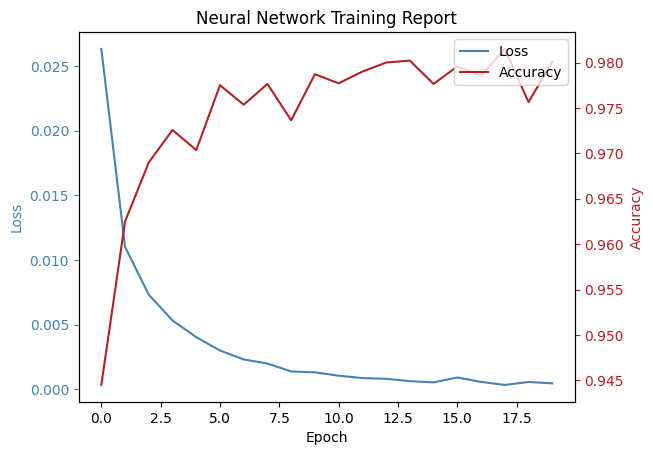

In [15]:
graphics.plot_report(neural_net)

In [16]:
#neural_net.export("../models/MNIST_net.h5")

In [17]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred_accuracy = np.where(y_pred > 0.5, 1, 0)
print(f"Accuracy: {accuracy_score(y_pred_accuracy, y_test)}")

Accuracy: 0.9800714285714286


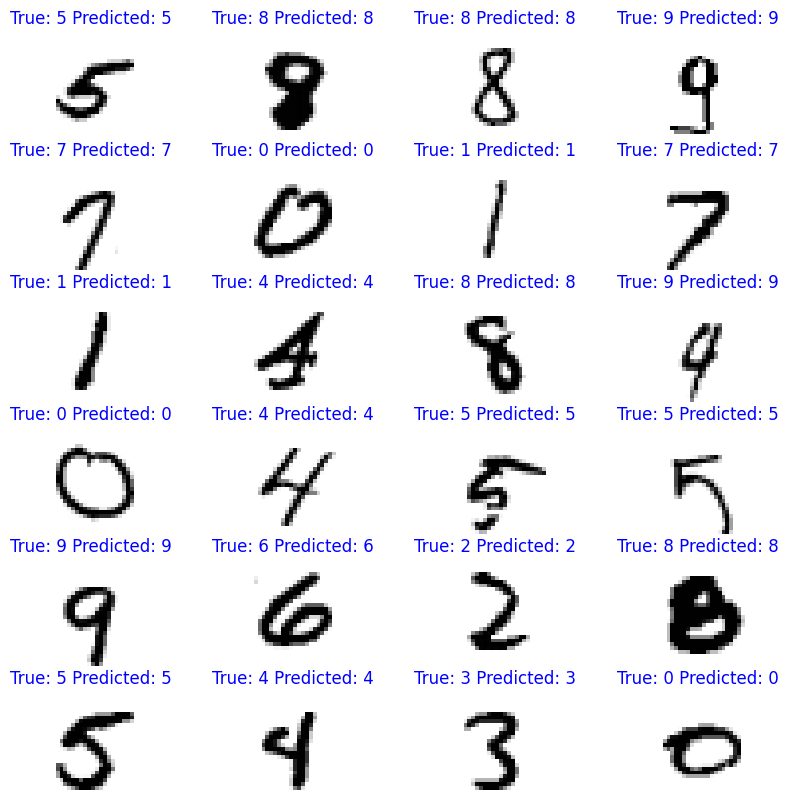

In [18]:
def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows*cols):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+100, y_test.argmax(axis=1)[i+100], y_pred.argmax(axis=1)[i+100])
plt.show()

Num wrong predictions: 272 out of 14000


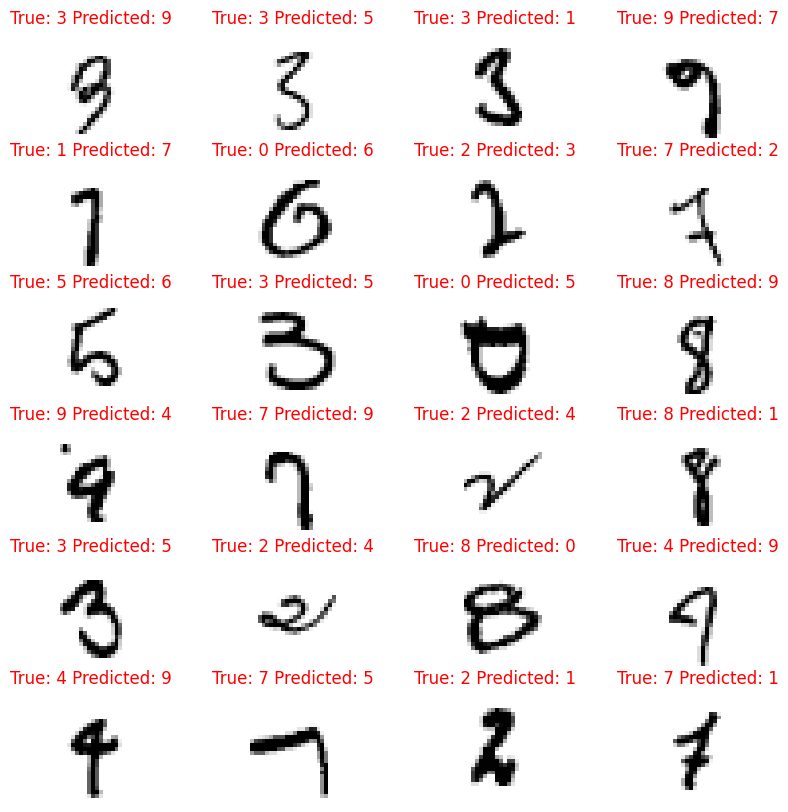

In [19]:

wrong_indices = y_test.argmax(axis=1) != y_pred.argmax(axis=1)
y_test_wrong = y_test.argmax(axis=1)[wrong_indices]
y_pred_wrong = y_pred.argmax(axis=1)[wrong_indices]
X_wrong = X_test[wrong_indices]

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(rows*cols):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_wrong, i, y_test_wrong[i], y_pred_wrong[i])
print(f"Num wrong predictions: {len(X_wrong)} out of {len(X_test)}")
plt.show()

Pred: [[4.8792031e-13 5.9860642e-21 1.4415969e-05 9.9998558e-01 5.0793632e-26
  3.2647083e-09 3.9880894e-09 8.4497153e-16 2.9989183e-16 8.5933752e-20]]


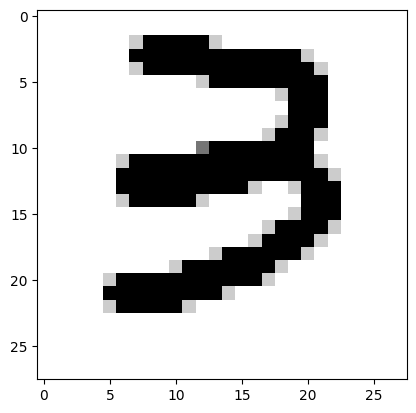

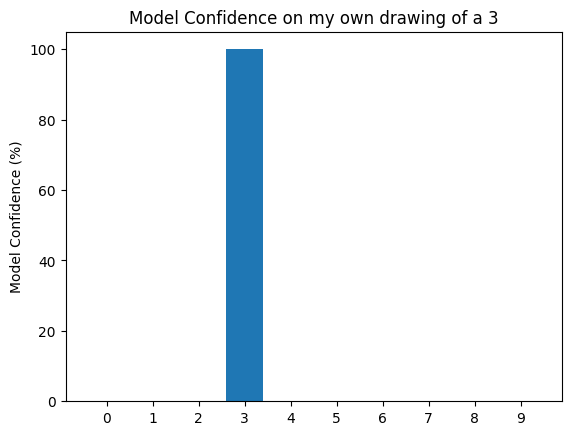

In [20]:
# can it predict my own writing?

my_three = plt.imread('examples/three.png')[:, :28, 0]
X_my = np.array([(1 - my_three).flatten()])
y_pred_my = neural_net.predict(X_my)
print(f"Pred: {y_pred_my}")
plt.imshow(my_three, cmap="gray")
plt.show()
plt.title("Model Confidence on my own drawing of a 3")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred_my.flatten())
plt.xticks(np.arange(10))
plt.show()